# EDA: relacion usuarios, parcelas y cultivos

Este notebook analiza unicamente la relacion entre agricultores/usuarios, sus parcelas y el cultivo activo de cada parcela en MILPIN.

Fuente de datos local: `../data/synthetic/usuarios.csv`, `../data/synthetic/parcelas.csv` y `../data/synthetic/cultivos_catalogo.csv`.

Relacion validada contra `backend/models.py` y `backend/schema.sql`:
- `usuarios.id_usuario` -> `parcelas.id_usuario`
- `cultivos_catalogo.id_cultivo` -> `parcelas.id_cultivo_actual`

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# MILPÍN — Auto-guardado en ML/images/
# Generado por ML/patch_notebooks.py — NO editar manualmente.
# ═══════════════════════════════════════════════════════════════════
from pathlib import Path
import sys as _sys
import re  as _re
import atexit as _atexit

# ── Directorio de salida ─────────────────────────────────────────────────────
_here = Path().resolve()
IMAGES_DIR = (
    _here.parent / "images"
    if _here.name == "experiments"
    else _here / "ML" / "images"
)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# ── Parche matplotlib: auto-save en plt.show() + redirigir plt.savefig ───────
import matplotlib.pyplot   as _plt
import matplotlib.figure   as _mpl_fig

_saved_fig_ids  = set()
_auto_fig_count = [0]
_orig_plt_show    = _plt.show
_orig_plt_savefig = _plt.savefig
_orig_fig_savefig = _mpl_fig.Figure.savefig

def _auto_fname(fig, n):
    title = (fig._suptitle.get_text() if fig._suptitle else "") or next(
        (ax.get_title() for ax in fig.get_axes() if ax.get_title()), "")
    stem = _re.sub(r"[^\w\-]", "_", title)[:50].strip("_").lower() if title else f"figura_{n:03d}"
    return f"{stem}.png"

def _patched_plt_savefig(fname, *a, **kw):
    dest = IMAGES_DIR / Path(str(fname)).name
    fig  = _plt.gcf()
    _orig_fig_savefig(fig, dest, *a, **kw)  # llama directo para evitar doble-parche
    _saved_fig_ids.add(id(fig))
    print(f"  ✓ [imagen] {dest.name}")

def _patched_fig_savefig(self, fname, *a, **kw):
    dest = IMAGES_DIR / Path(str(fname)).name
    _orig_fig_savefig(self, dest, *a, **kw)
    _saved_fig_ids.add(id(self))
    print(f"  ✓ [imagen] {dest.name}")

def _patched_plt_show(*a, **kw):
    fig = _plt.gcf()
    if fig.get_axes() and id(fig) not in _saved_fig_ids:
        _auto_fig_count[0] += 1
        fname = _auto_fname(fig, _auto_fig_count[0])
        _orig_fig_savefig(fig, IMAGES_DIR / fname, dpi=150, bbox_inches="tight")
        print(f"  ✓ [auto-imagen] {fname}")
    _saved_fig_ids.discard(id(fig))
    _orig_plt_show(*a, **kw)

_plt.show               = _patched_plt_show
_plt.savefig            = _patched_plt_savefig
_mpl_fig.Figure.savefig = _patched_fig_savefig

# ── Parche pandas: auto-save DataFrames al mostrarse en Jupyter ─────────────
_df_count = [0]
try:
    import pandas as _pd
    _orig_df_repr_html = _pd.DataFrame._repr_html_

    def _patched_df_repr_html(self):
        _df_count[0] += 1
        stem = f"tabla_{_df_count[0]:03d}"
        self.to_csv(IMAGES_DIR / f"{stem}.csv", index=True, encoding="utf-8-sig")
        self.to_html(IMAGES_DIR / f"{stem}.html")
        print(f"  ✓ [tabla] {stem}.csv  ({len(self)} filas × {len(self.columns)} cols)")
        return _orig_df_repr_html(self)

    _pd.DataFrame._repr_html_ = _patched_df_repr_html
except Exception as _pd_err:
    print(f"  ! pandas hook: {_pd_err}")

# ── Capturar stdout → IMAGES_DIR/output_log.txt ──────────────────────────────
_log_path = IMAGES_DIR / "output_log.txt"
_log_file = open(_log_path, "w", encoding="utf-8")

class _Tee:
    def __init__(self, real, log):
        self._real = real
        self._log  = log
    def write(self, s):
        self._real.write(s)
        self._log.write(s)
    def flush(self):
        self._real.flush()
        self._log.flush()
    def __getattr__(self, attr):
        return getattr(self._real, attr)

_sys.stdout = _Tee(_sys.__stdout__, _log_file)
_atexit.register(lambda: (_log_file.flush(), _log_file.close()))

print(f"✓ IMAGES_DIR  → {IMAGES_DIR}")
print(f"✓ matplotlib  → auto-save en show() + redirigir savefig()")
print(f"✓ pandas      → auto-save DataFrames (CSV + HTML)")
print(f"✓ stdout      → {_log_path.name}")


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 80)

## 1. Carga de datos

El notebook se ejecuta desde `ML/`. Por eso `DATA_DIR` apunta a `../data/synthetic/`.

In [2]:
DATA_DIR = Path("..") / "data" / "synthetic"

usuarios = pd.read_csv(DATA_DIR / "usuarios.csv")
parcelas = pd.read_csv(DATA_DIR / "parcelas.csv")
cultivos = pd.read_csv(DATA_DIR / "cultivos_catalogo.csv")

print(f"Usuarios: {usuarios.shape[0]:,} filas x {usuarios.shape[1]} columnas")
print(f"Parcelas: {parcelas.shape[0]:,} filas x {parcelas.shape[1]} columnas")
print(f"Cultivos: {cultivos.shape[0]:,} filas x {cultivos.shape[1]} columnas")

Usuarios: 20 filas x 7 columnas
Parcelas: 80 filas x 14 columnas
Cultivos: 5 filas x 12 columnas


In [3]:
usuarios.head()

,id_usuario,nombre_completo,email,telefono,modulo_dr041,activo,created_at
0,66dc7715-a8ed-48c7-908b-83f76b01312e,Ramón Valenzuela,ramon.valenzuela000@dr041-dev.com,526441803258,Módulo 4,True,2025-01-22T16:57:03+00:00
1,641616f1-6d0a-4fa6-9a0a-29c1bb2d84a6,María Fernández,maria.fernandez001@dr041-dev.com,526448727380,Módulo 1,True,2024-12-22T23:17:03+00:00
2,d04b7eb5-cb55-46ff-94f2-cf982296b5b2,Juan Carlos Ortiz,juan.carlos.ortiz002@dr041-dev.com,526445738310,Módulo 5,True,2024-11-25T08:39:03+00:00
3,4dfb1bcc-997a-41a2-825d-78c9fc95044d,Luis Miranda,luis.miranda003@dr041-dev.com,526448074577,Módulo 3,True,2026-02-05T06:55:03+00:00
4,eef355b8-2cc5-4979-8c38-150728a4e340,Rosa Herrera,rosa.herrera004@dr041-dev.com,526445503166,Módulo 2,True,2025-12-28T04:36:03+00:00


In [4]:
parcelas[[
    "id_parcela", "id_usuario", "id_cultivo_actual", "nombre_parcela",
    "area_ha", "tipo_suelo", "sistema_riego", "activo"
]].head()

,id_parcela,id_usuario,id_cultivo_actual,nombre_parcela,area_ha,tipo_suelo,sistema_riego,activo
0,63b4f127-a33b-462d-94a1-1b5da940952d,4dfb1bcc-997a-41a2-825d-78c9fc95044d,b1c20edc-4510-4002-a730-5ad4356dba91,Lote Maí-001,18.8866,arcilloso,gravedad,True
1,ce83cb07-58f6-4daf-a6e3-1ee72480447b,4b54daf2-987b-4059-a1b6-5e2a1983d28c,b1c20edc-4510-4002-a730-5ad4356dba91,Lote Maí-002,12.5542,franco,aspersion,True
2,5ddf7399-e390-4a8e-ace0-651a67542da2,bec519f0-27d3-40aa-8702-3f9daf62b70e,b6e29a2a-a7a6-4cfc-b00d-0dbb8304729d,Lote Fri-003,14.5567,arenoso,microaspersion,True
3,eebee71b-b00b-4a44-b941-73e1c260c706,3df7dd0d-8656-4a87-9657-e5b6465bf9fd,3fae9720-89c2-4356-adb9-cd54f91d3882,Lote Chi-004,18.2952,arcilloso,gravedad,True
4,b1da7fe5-e177-4f94-81e5-3dad69d2c13d,86da88b3-dbc3-4bdf-89ec-0d84cbf360fe,b6e29a2a-a7a6-4cfc-b00d-0dbb8304729d,Lote Fri-005,9.6925,franco-arenoso,gravedad,True


In [5]:
cultivos[["id_cultivo", "nombre_comun", "nombre_cientifico"]]

,id_cultivo,nombre_comun,nombre_cientifico
0,b1c20edc-4510-4002-a730-5ad4356dba91,Maíz,Zea mays
1,b6e29a2a-a7a6-4cfc-b00d-0dbb8304729d,Frijol,Phaseolus vulgaris
2,0f3f1ca9-4c69-43ae-85c5-6d898bb6fe99,Algodón,Gossypium hirsutum
3,835d37d0-113b-4f76-a102-005e5bf14054,Uva,Vitis vinifera
4,3fae9720-89c2-4356-adb9-cd54f91d3882,Chile,Capsicum annuum


## 2. Validacion minima de relaciones

Antes de unir tablas, se revisa si hay parcelas sin usuario valido o sin cultivo valido. Esto detecta problemas de integridad referencial en los CSV.

In [6]:
usuarios_ids = set(usuarios["id_usuario"])
cultivos_ids = set(cultivos["id_cultivo"])

parcelas_sin_usuario = parcelas.loc[~parcelas["id_usuario"].isin(usuarios_ids)]
parcelas_sin_cultivo = parcelas.loc[
    parcelas["id_cultivo_actual"].notna()
    & ~parcelas["id_cultivo_actual"].isin(cultivos_ids)
]

resumen_integridad = pd.DataFrame({
    "revision": ["parcelas_sin_usuario", "parcelas_sin_cultivo_catalogado"],
    "conteo": [len(parcelas_sin_usuario), len(parcelas_sin_cultivo)],
})
resumen_integridad

,revision,conteo
0,parcelas_sin_usuario,0
1,parcelas_sin_cultivo_catalogado,0


## 3. Dataset unido para el EDA

La tabla analitica resultante conserva una fila por parcela y agrega datos legibles del usuario y del cultivo activo.

In [7]:
parcelas_eda = (
    parcelas
    .merge(
        usuarios[["id_usuario", "nombre_completo", "email", "modulo_dr041", "activo"]]
        .rename(columns={"activo": "usuario_activo"}),
        on="id_usuario",
        how="left",
        validate="many_to_one",
    )
    .merge(
        cultivos[["id_cultivo", "nombre_comun", "nombre_cientifico"]],
        left_on="id_cultivo_actual",
        right_on="id_cultivo",
        how="left",
        validate="many_to_one",
    )
    .rename(columns={
        "nombre_completo": "usuario",
        "nombre_comun": "cultivo",
        "nombre_cientifico": "cultivo_cientifico",
    })
)

parcelas_eda[[
    "usuario", "email", "modulo_dr041", "nombre_parcela", "cultivo",
    "area_ha", "tipo_suelo", "sistema_riego", "activo", "usuario_activo"
]].head(10)

,usuario,email,modulo_dr041,nombre_parcela,cultivo,area_ha,tipo_suelo,sistema_riego,activo,usuario_activo
0,Luis Miranda,luis.miranda003@dr041-dev.com,Módulo 3,Lote Maí-001,Maíz,18.8866,arcilloso,gravedad,True,True
1,Sergio Bojórquez,sergio.bojorquez009@dr041-dev.com,Módulo 3,Lote Maí-002,Maíz,12.5542,franco,aspersion,True,True
2,Jesús Soto,jesus.soto005@dr041-dev.com,Módulo 3,Lote Fri-003,Frijol,14.5567,arenoso,microaspersion,True,True
3,Beatriz Gaxiola,beatriz.gaxiola014@dr041-dev.com,Módulo 1,Lote Chi-004,Chile,18.2952,arcilloso,gravedad,True,True
4,Claudia Navarro,claudia.navarro012@dr041-dev.com,Módulo 4,Lote Fri-005,Frijol,9.6925,franco-arenoso,gravedad,True,True
5,Ernesto Zamora,ernesto.zamora013@dr041-dev.com,Módulo 5,Lote Uva-006,Uva,8.7642,franco-arenoso,microaspersion,True,True
6,Rosa Herrera,rosa.herrera004@dr041-dev.com,Módulo 2,Lote Maí-007,Maíz,7.8311,arcilloso,gravedad,True,True
7,Jesús Soto,jesus.soto005@dr041-dev.com,Módulo 3,Lote Maí-008,Maíz,9.9851,franco-limoso,gravedad,True,True
8,María Fernández,maria.fernandez001@dr041-dev.com,Módulo 1,Lote Chi-009,Chile,32.5767,franco-arcilloso,gravedad,True,True
9,Juan Carlos Ortiz,juan.carlos.ortiz002@dr041-dev.com,Módulo 5,Lote Fri-010,Frijol,6.7294,franco-arcilloso,gravedad,True,True


## 4. Resumen ejecutivo del cruce

Estos indicadores contestan: cuantos usuarios tienen parcelas, cuantas parcelas hay, cuantos cultivos aparecen y que superficie esta asignada.

In [8]:
resumen = pd.DataFrame({
    "indicador": [
        "usuarios_totales",
        "usuarios_con_parcelas",
        "parcelas_totales",
        "cultivos_presentes_en_parcelas",
        "area_total_ha",
        "area_promedio_por_parcela_ha",
    ],
    "valor": [
        usuarios["id_usuario"].nunique(),
        parcelas_eda["id_usuario"].nunique(),
        parcelas_eda["id_parcela"].nunique(),
        parcelas_eda["cultivo"].nunique(dropna=True),
        round(parcelas_eda["area_ha"].sum(), 2),
        round(parcelas_eda["area_ha"].mean(), 2),
    ],
})
resumen

,indicador,valor
0,usuarios_totales,20.00
1,usuarios_con_parcelas,20.00
2,parcelas_totales,80.00
3,cultivos_presentes_en_parcelas,5.00
4,area_total_ha,1068.30
5,area_promedio_por_parcela_ha,13.35


## 5. Parcelas por usuario

Muestra la carga de parcelas por agricultor/usuario.

In [9]:
parcelas_por_usuario = (
    parcelas_eda
    .groupby(["id_usuario", "usuario", "email", "modulo_dr041"], dropna=False)
    .agg(
        parcelas=("id_parcela", "nunique"),
        area_total_ha=("area_ha", "sum"),
        cultivos_distintos=("cultivo", "nunique"),
    )
    .reset_index()
    .sort_values(["parcelas", "area_total_ha"], ascending=False)
)

parcelas_por_usuario.head(15)

,id_usuario,usuario,email,modulo_dr041,parcelas,area_total_ha,cultivos_distintos
14,c715a03e-8a15-48da-a4a6-54a73357d2fe,Leticia Romo,leticia.romo018@dr041-dev.com,Módulo 5,9,129.8030,4
10,86da88b3-dbc3-4bdf-89ec-0d84cbf360fe,Claudia Navarro,claudia.navarro012@dr041-dev.com,Módulo 4,7,98.1681,4
2,4825ddd9-00a0-4e92-8e03-a51ab3f4bf90,Francisco Acosta,francisco.acosta015@dr041-dev.com,Módulo 2,6,89.2763,4
1,3df7dd0d-8656-4a87-9657-e5b6465bf9fd,Beatriz Gaxiola,beatriz.gaxiola014@dr041-dev.com,Módulo 1,5,83.4391,3
13,bec519f0-27d3-40aa-8702-3f9daf62b70e,Jesús Soto,jesus.soto005@dr041-dev.com,Módulo 3,5,71.1675,4
11,97a9f5b0-041d-4739-b285-4c44ef5237dd,Patricia Durán,patricia.duran010@dr041-dev.com,Módulo 1,5,66.1051,4
12,a1774f72-bc2b-4778-a19e-ffa60bb66546,Silvia Ibarra,silvia.ibarra016@dr041-dev.com,Módulo 3,5,57.8756,3
8,774d6b2a-61bc-4796-81e5-b039bdfbd52c,Norma Reyes,norma.reyes008@dr041-dev.com,Módulo 4,5,57.0228,3
17,dbb7ddd7-c750-4d47-90f6-6106783ab3db,Guadalupe Ríos,guadalupe.rios006@dr041-dev.com,Módulo 2,5,43.2733,3
9,77890133-fd37-4e83-b67d-0a80b3e059ca,Ernesto Zamora,ernesto.zamora013@dr041-dev.com,Módulo 5,4,55.3446,3


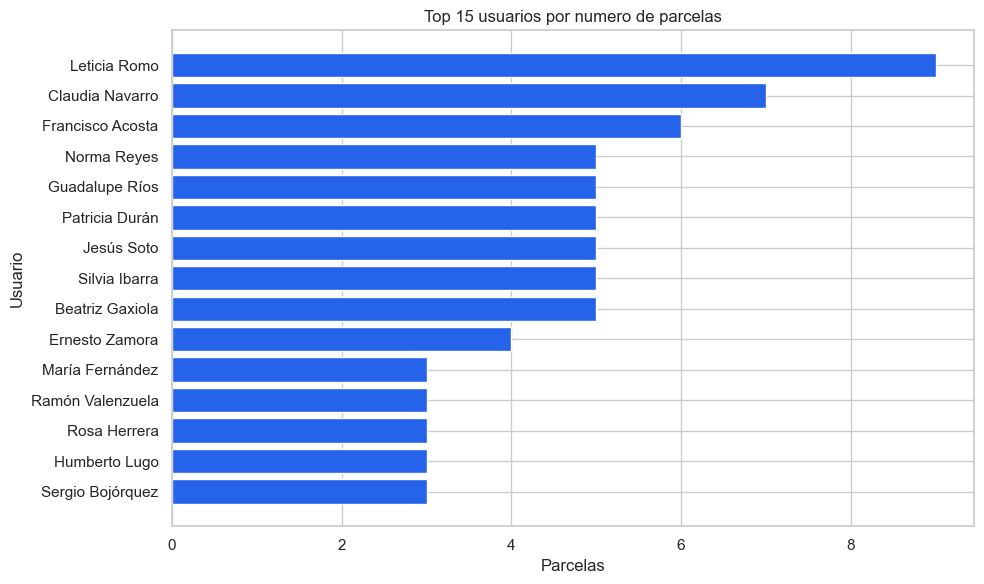

In [10]:
top_usuarios = parcelas_por_usuario.head(15).sort_values("parcelas")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_usuarios["usuario"], top_usuarios["parcelas"], color="#2563eb")
ax.set_title("Top 15 usuarios por numero de parcelas")
ax.set_xlabel("Parcelas")
ax.set_ylabel("Usuario")
plt.tight_layout()

## 6. Cultivos presentes en las parcelas

Distribucion de parcelas y superficie por cultivo activo.

In [11]:
cultivos_en_parcelas = (
    parcelas_eda
    .groupby("cultivo", dropna=False)
    .agg(
        parcelas=("id_parcela", "nunique"),
        usuarios=("id_usuario", "nunique"),
        area_total_ha=("area_ha", "sum"),
        area_promedio_ha=("area_ha", "mean"),
    )
    .reset_index()
    .sort_values("parcelas", ascending=False)
)

cultivos_en_parcelas

,cultivo,parcelas,usuarios,area_total_ha,area_promedio_ha
3,Maíz,22,14,269.0373,12.228968
1,Chile,18,12,303.3411,16.852283
2,Frijol,17,11,220.8075,12.988676
4,Uva,13,10,156.3299,12.025377
0,Algodón,10,9,118.7810,11.878100


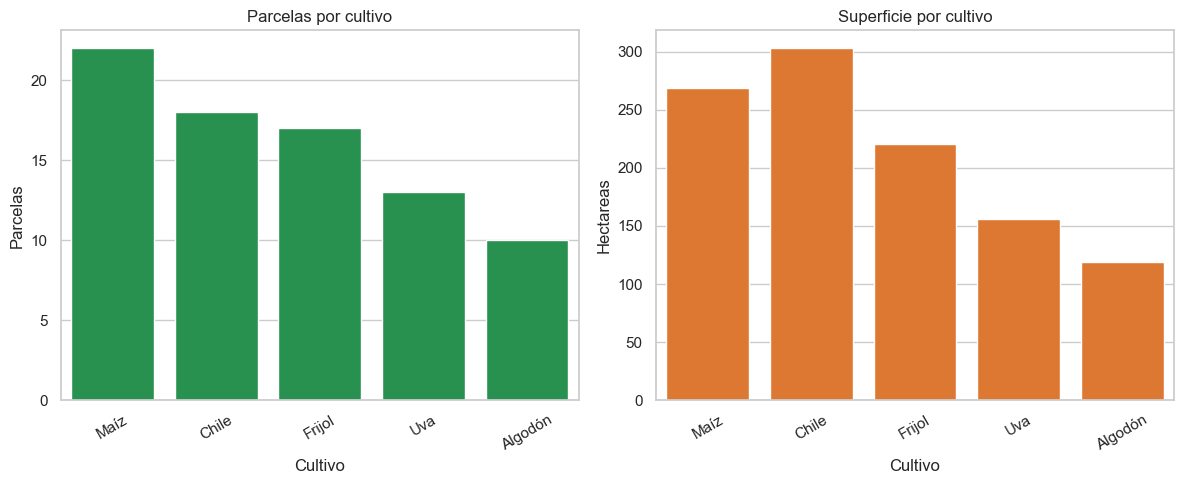

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=cultivos_en_parcelas,
    x="cultivo",
    y="parcelas",
    ax=axes[0],
    color="#16a34a",
)
axes[0].set_title("Parcelas por cultivo")
axes[0].set_xlabel("Cultivo")
axes[0].set_ylabel("Parcelas")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=cultivos_en_parcelas,
    x="cultivo",
    y="area_total_ha",
    ax=axes[1],
    color="#f97316",
)
axes[1].set_title("Superficie por cultivo")
axes[1].set_xlabel("Cultivo")
axes[1].set_ylabel("Hectareas")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()

## 7. Matriz usuario x cultivo

Esta matriz permite ver que cultivos tiene cada usuario y cuantas parcelas tiene por cultivo.

In [13]:
matriz_usuario_cultivo = pd.crosstab(
    parcelas_eda["usuario"],
    parcelas_eda["cultivo"],
    values=parcelas_eda["id_parcela"],
    aggfunc="count",
).fillna(0).astype(int)

matriz_usuario_cultivo.loc[matriz_usuario_cultivo.sum(axis=1).sort_values(ascending=False).index].head(20)

cultivo,Algodón,Chile,Frijol,Maíz,Uva
usuario,,,,,
Leticia Romo,0,2,1,4,2
Claudia Navarro,0,1,4,1,1
Francisco Acosta,0,1,1,3,1
Beatriz Gaxiola,1,2,2,0,0
Patricia Durán,1,0,1,2,1
Silvia Ibarra,0,3,1,1,0
Jesús Soto,0,2,1,1,1
Guadalupe Ríos,1,0,2,2,0
Norma Reyes,0,0,2,1,2


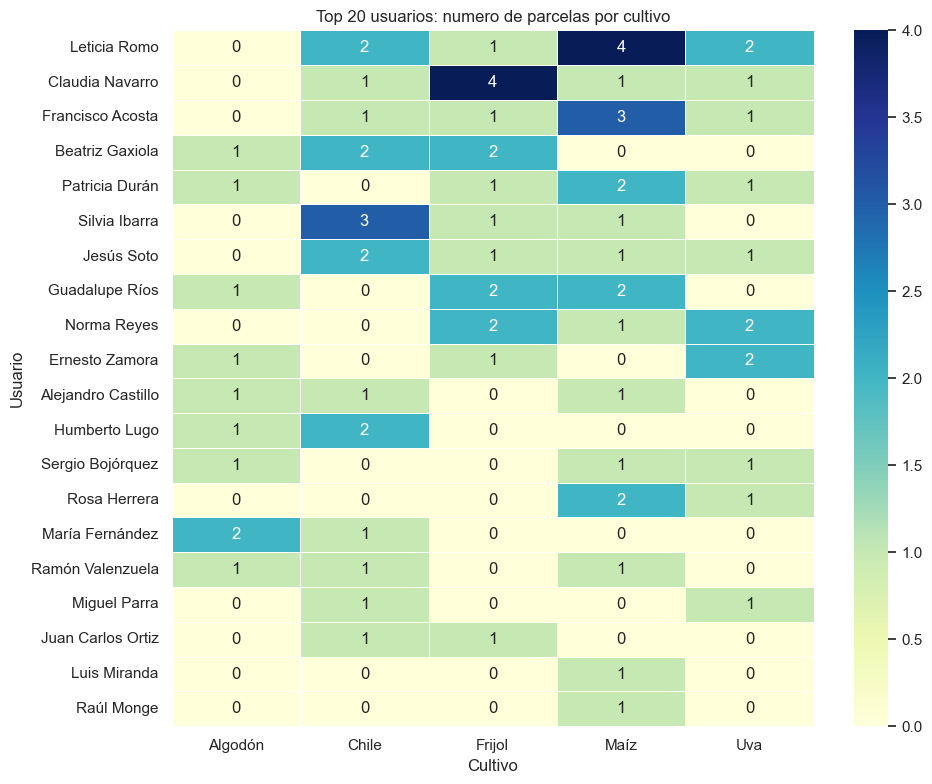

In [14]:
matriz_top = matriz_usuario_cultivo.loc[
    matriz_usuario_cultivo.sum(axis=1).sort_values(ascending=False).head(20).index
]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matriz_top, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5, ax=ax)
ax.set_title("Top 20 usuarios: numero de parcelas por cultivo")
ax.set_xlabel("Cultivo")
ax.set_ylabel("Usuario")
plt.tight_layout()

## 8. Detalle final por parcela

Tabla limpia para revisar la relacion completa: usuario -> parcela -> cultivo.

In [15]:
detalle_parcelas = (
    parcelas_eda[[
        "usuario", "email", "modulo_dr041", "nombre_parcela", "cultivo",
        "cultivo_cientifico", "area_ha", "tipo_suelo", "sistema_riego",
        "activo", "usuario_activo",
    ]]
    .sort_values(["usuario", "cultivo", "nombre_parcela"])
    .reset_index(drop=True)
)

detalle_parcelas

,usuario,email,modulo_dr041,nombre_parcela,cultivo,cultivo_cientifico,area_ha,tipo_suelo,sistema_riego,activo,usuario_activo
0,Alejandro Castillo,alejandro.castillo007@dr041-dev.com,Módulo 5,Lote Alg-033,Algodón,Gossypium hirsutum,9.4156,franco,microaspersion,True,True
1,Alejandro Castillo,alejandro.castillo007@dr041-dev.com,Módulo 5,Lote Chi-044,Chile,Capsicum annuum,11.3777,franco,gravedad,True,True
2,Alejandro Castillo,alejandro.castillo007@dr041-dev.com,Módulo 5,Lote Maí-035,Maíz,Zea mays,5.3980,arenoso,gravedad,True,True
3,Beatriz Gaxiola,beatriz.gaxiola014@dr041-dev.com,Módulo 1,Lote Alg-069,Algodón,Gossypium hirsutum,29.7524,franco-limoso,aspersion,True,True
4,Beatriz Gaxiola,beatriz.gaxiola014@dr041-dev.com,Módulo 1,Lote Chi-004,Chile,Capsicum annuum,18.2952,arcilloso,gravedad,True,True
...,...,...,...,...,...,...,...,...,...,...,...
75,Silvia Ibarra,silvia.ibarra016@dr041-dev.com,Módulo 3,Lote Chi-011,Chile,Capsicum annuum,22.9143,franco-arcilloso,gravedad,True,True
76,Silvia Ibarra,silvia.ibarra016@dr041-dev.com,Módulo 3,Lote Chi-034,Chile,Capsicum annuum,9.2988,arenoso,gravedad,True,True
77,Silvia Ibarra,silvia.ibarra016@dr041-dev.com,Módulo 3,Lote Chi-052,Chile,Capsicum annuum,6.4315,franco-arenoso,gravedad,True,True
78,Silvia Ibarra,silvia.ibarra016@dr041-dev.com,Módulo 3,Lote Fri-053,Frijol,Phaseolus vulgaris,10.4611,franco-arcilloso,microaspersion,True,True
